# A figure to show the before and after af the removal of the ac stark shift
- currently imagining a figure with two side by sides of rabi and ccd with their ac stark shift removed

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [3]:
steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


In [4]:

import os
import sys


# --- PATH modification for TinyTeX (BEGIN) ---
tinytex_bin_path = os.path.expanduser("~/Library/TinyTeX/bin/universal-darwin")
if os.path.exists(tinytex_bin_path):
    if tinytex_bin_path not in os.environ['PATH']:
        os.environ['PATH'] = tinytex_bin_path + os.pathsep + os.environ['PATH']
        print(f"Added {tinytex_bin_path} to PATH for this Python session.")
    else:
        print(f"{tinytex_bin_path} already in PATH for this session.")
else:
    print(f"Warning: TinyTeX bin path not found at {tinytex_bin_path}. LaTeX rendering might fail.")
# --- PATH modification for TinyTeX (END) ---


# --- Matplotlib Configuration for LaTeX Integration ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}""",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 12,
    "axes.titlesize": 10,
})



# --- Figure Dimensions for Your LaTeX Document ---
pt_to_inches = 1.0 / 72.27
latex_textwidth_pts = 469.75502 # Standard for A4 article, 10pt
latex_fig_width_inches =1 * latex_textwidth_pts * pt_to_inches  

# Calculate column width: (textwidth - columnsep) / 2
# Your LaTeX sets \columnsep to 0.75cm. Convert 0.75cm to points.
# column_sep_cm = 0.75
# column_sep_pts = column_sep_cm * (72.27 / 2.54) # 72.27 pts/inch, 2.54 cm/inch

# latex_column_width_pts = (latex_textwidth_pts - column_sep_pts) / 2

# # Set figure width to match the calculated column width
# latex_fig_width_inches = latex_column_width_pts * pt_to_inches


# latex_fig_height_inches = latex_fig_width_inches


/Users/archie/Library/TinyTeX/bin/universal-darwin already in PATH for this session.


## Rabi


In [5]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-7
evaluation_points = 2001
evaluation_time = 8/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 4*rabi_freq, 1000)



fids_rabi_raw = []
fids_rabi_det_compensated = []
fids_rabi_ac_compensated = []




for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)

    # calculate how the bare detuned qubit fairs
    fid_rabi_raw = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    fids_rabi_raw.append(fid_rabi_raw)


    # then compensate for the ac stark effect and recalculate the fidelity
    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_rabi_ac_compensated = qt.calculate_fidelities(identity, Us_effective_rabi, 2)
    fids_rabi_ac_compensated.append(fid_rabi_ac_compensated)

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, -detuning, times)
    fid_rabi_det_compensated = qt.calculate_fidelities(identity, transformed_Us, 2)
    fids_rabi_det_compensated.append(fid_rabi_det_compensated)



In [6]:
# Find the closest time to the optimal measurement time
closest_time = times[np.argmin(np.abs(times - (4 / rabi_freq)))]
time_index = np.argmin(np.abs(times - (4 / rabi_freq)))

# Extract fidelities at the optimal measurement time
final_fids_rabi_raw = [fid[time_index] for fid in fids_rabi_raw]
final_fids_rabi_det = [fid[time_index] for fid in fids_rabi_det_compensated]
final_fids_rabi_ac = [fid[time_index] for fid in fids_rabi_ac_compensated]

# Normalize detunings
detunings_normalized = detunings / rabi_freq

## CCD

In [15]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
# Integration parameters
tol = 10**-7
evaluation_points = 2001
evaluation_time = 8/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 4*rabi_freq, 1000)



fids_ccd_raw = []
fids_ccd_det_compensated = []
fids_ccd_rabi_compensated = []
fids_ccd_ac_compensated = []


for detuning in detunings:
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol, rtol=tol)
    

    fid_ccd_raw = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    fids_ccd_raw.append(fid_ccd_raw)
    # then compensate for the ac stark effect and recalculate the fidelity

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)
    
    fid_ccd_compensated = qt.calculate_fidelities(identity, transformed_Us, 2)

    

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, effective_rabi_freq, times)
    fid_ccd_rabi_compensated = qt.calculate_fidelities(identity, Us_effective_rabi, 2)
    fids_ccd_rabi_compensated.append(fid_ccd_rabi_compensated)

    fids_ccd_ac_compensated.append(fid_ccd_compensated)

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, detuning, times)
    fid_ccd_det_compensated = qt.calculate_fidelities(identity, transformed_Us, 2)
    fids_ccd_det_compensated.append(fid_ccd_det_compensated)




In [ ]:
# Find the closest time to the optimal measurement time
closest_time = times[np.argmin(np.abs(times - (4 / rabi_freq)))]
time_index = np.argmin(np.abs(times - (4 / rabi_freq)))

# Extract fidelities at the optimal measurement time
final_fids_ccd_raw = [fid[time_index] for fid in fids_ccd_raw]
final_fids_ccd_det = [fid[time_index] for fid in fids_ccd_det_compensated]
final_fids_ccd_rabi = [fid[time_index] for fid in fids_ccd_rabi_compensated]
final_fids_ccd_ac = [fid[time_index] for fid in fids_ccd_ac_compensated]

# Normalize detunings
detunings_normalized = detunings / rabi_freq

# now create the combined plot

In [17]:
vmin = 1/3
vmax = 1
detuning_scale = detunings/rabi_freq
time_scale = times*rabi_freq

In [18]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}""",
    "font.size": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.titlesize": 14,
    "axes.titlesize": 14,
})



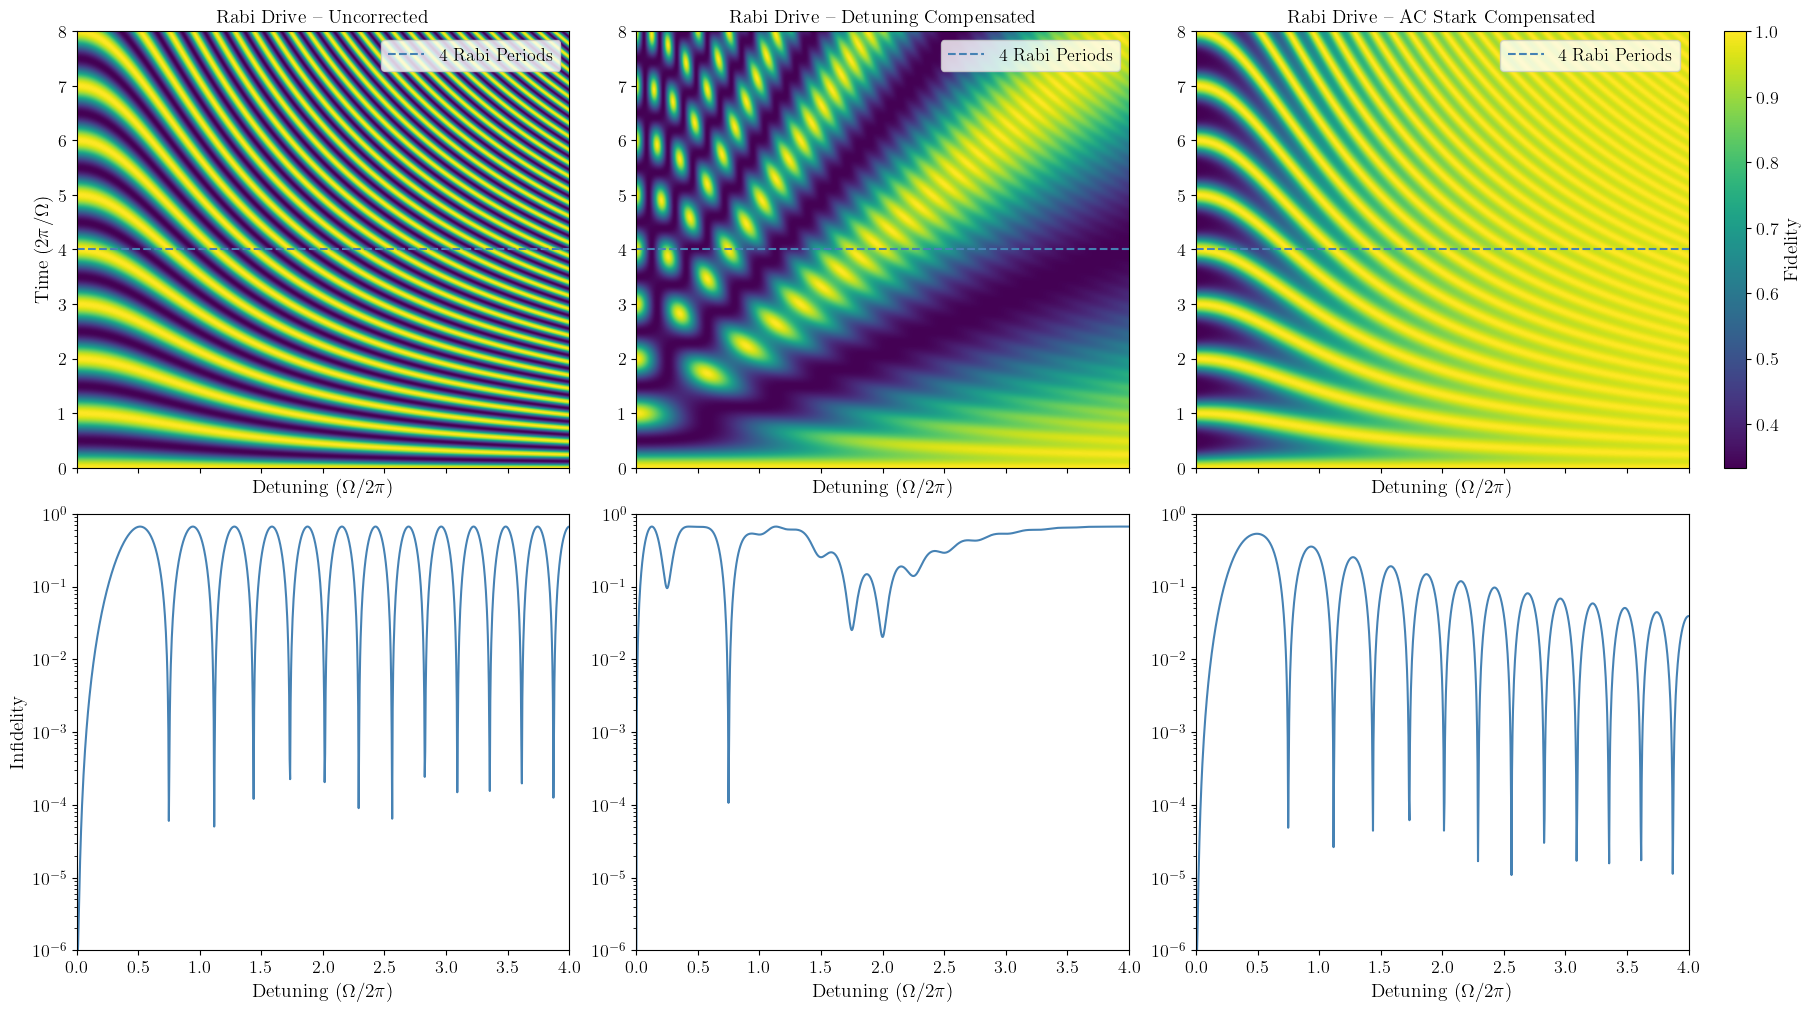

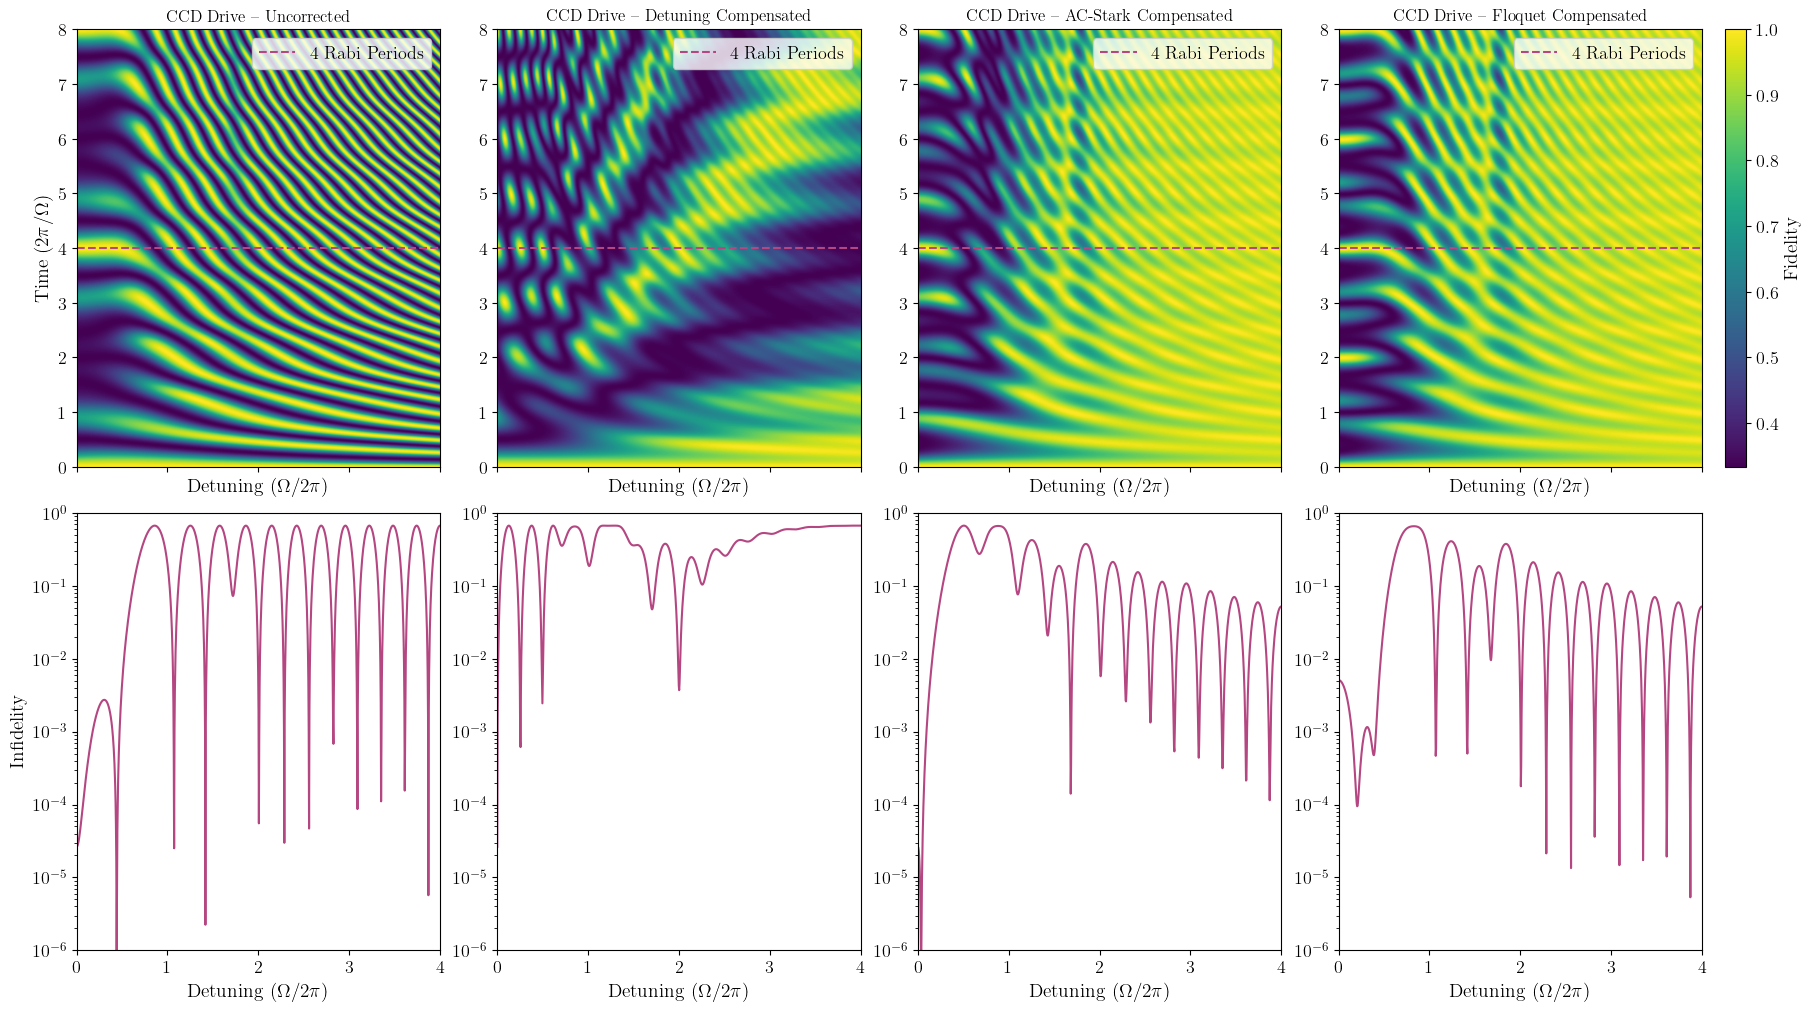

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# === RABI Infidelity Plot ===
fig_rabi, axs_rabi = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

titles_rabi = [
    'Rabi Drive – Uncorrected',
    'Rabi Drive – Detuning Compensated',
    'Rabi Drive – AC Stark Compensated'
]

data_rabi = [
    fids_rabi_raw,
    fids_rabi_det_compensated,
    fids_rabi_ac_compensated
]

infidelity_data_rabi = [
    1 - np.array(final_fids_rabi_raw),
    1 - np.array(final_fids_rabi_det),
    1 - np.array(final_fids_rabi_ac)
]

# Plot Rabi fidelity heatmaps (top row)
for ax, title, fid in zip(axs_rabi[0], titles_rabi, data_rabi):
    im = ax.imshow(
        np.array(fid).T, aspect='auto',
        extent=[detunings_normalized[0], detunings_normalized[-1], time_scale[0], time_scale[-1]],
        origin='lower', cmap='viridis',
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title)
    ax.set_xlabel(r'Detuning ($\Omega/2\pi$)')
    ax.axhline(4, color=steel_blue, linestyle='--', label='4 Rabi Periods')
    ax.legend(loc='upper right')
axs_rabi[0, 0].set_ylabel(r'Time ($2\pi/\Omega$)')

# Plot Rabi infidelity (semilog y-axis) (bottom row)
for ax, infidelity in zip(axs_rabi[1], infidelity_data_rabi):
    ax.semilogy(detunings_normalized, infidelity, color=steel_blue)
    ax.set_xlabel(r'Detuning ($\Omega/2\pi$)')
    ax.set_ylim(1e-6, 1)
axs_rabi[1,0].set_ylabel('Infidelity')

# Shared colorbar
# fig_rabi.colorbar(im, ax=axs_rabi[0, :], location='right', label='Fidelity')
cbar = fig_rabi.colorbar(im, ax=axs_rabi[0, 2])
cbar.set_label('Fidelity')

# fig_rabi.suptitle('Rabi Drive Compensation Comparison with Infidelity', fontsize=16)
fig_rabi.savefig('/Users/archie/documents/year4/project/Figures_Final/rabi_compensation_with_infidelity.pdf', dpi=600)
plt.show()


# === CCD Infidelity Plot ===
fig_ccd, axs_ccd = plt.subplots(2, 4, figsize=(18, 10), constrained_layout=True, sharex='col')

titles_ccd = [
    'CCD Drive – Uncorrected',
    'CCD Drive – Detuning Compensated',
    'CCD Drive – AC-Stark Compensated',
    'CCD Drive – Floquet Compensated'
]

data_ccd = [
    fids_ccd_raw,
    fids_ccd_det_compensated,
    fids_ccd_rabi_compensated,
    fids_ccd_ac_compensated
]

infidelity_data_ccd = [
    1 - np.array(final_fids_ccd_raw),
    1 - np.array(final_fids_ccd_det),
    1 - np.array(final_fids_ccd_rabi),
    1 - np.array(final_fids_ccd_ac)
]

# Plot CCD fidelity heatmaps (top row)
for ax, title, fid in zip(axs_ccd[0], titles_ccd, data_ccd):
    im = ax.imshow(
        np.array(fid).T, aspect='auto',
        extent=[detunings_normalized[0], detunings_normalized[-1], time_scale[0], time_scale[-1]],
        origin='lower', cmap='viridis',
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'Detuning ($\Omega/2\pi$)')
    ax.axhline(4, color=plum, linestyle='--', label='4 Rabi Periods')
    ax.legend(loc='upper right')
axs_ccd[0, 0].set_ylabel(r'Time ($2\pi/\Omega$)',)

# Plot CCD infidelity (semilog y-axis) (bottom row)
for ax, infidelity in zip(axs_ccd[1], infidelity_data_ccd):
    ax.semilogy(detunings_normalized, infidelity, color=plum)
    ax.set_xlabel(r'Detuning ($\Omega/2\pi$)')
    ax.set_ylim(1e-6, 1)
axs_ccd[1,0].set_ylabel('Infidelity')

# Shared colorbar
# fig_ccd.colorbar(im, ax=axs_ccd[0, :], location='right', label='Fidelity')
cbar = fig_ccd.colorbar(im, ax=axs_ccd[0, 3])
cbar.set_label('Fidelity')

# fig_ccd.suptitle('CCD Drive Compensation Comparison with Infidelity', fontsize=16)
fig_ccd.savefig('/Users/archie/documents/year4/project/Figures_Final/ccd_compensation_with_infidelity.pdf', dpi=600)
plt.show()

In [47]:
# Define the range of detunings (1 Rabi frequency to 4 Rabi frequencies)
start_detuning = 1 * rabi_freq
end_detuning = 4 * rabi_freq

# Find the indices corresponding to the range
start_index = np.argmin(np.abs(detunings - start_detuning))
end_index = np.argmin(np.abs(detunings - end_detuning))

# Extract the relevant infidelity data for the range
infidelity_frame_1 = 1 - np.array(final_fids_ccd_rabi)[start_index:end_index]
infidelity_frame_2 = 1 - np.array(final_fids_ccd_ac)[start_index:end_index]

# Calculate the average infidelity for each frame
average_infidelity_frame_1 = np.mean(infidelity_frame_1)
average_infidelity_frame_2 = np.mean(infidelity_frame_2)

# Print the results
print(f"Average Infidelity for Frame 1 (Rabi Compensated): {average_infidelity_frame_1}")
print(f"Average Infidelity for Frame 2 (AC-Stark Compensated): {average_infidelity_frame_2}")

Average Infidelity for Frame 1 (Rabi Compensated): 0.10196055729554589
Average Infidelity for Frame 2 (AC-Stark Compensated): 0.09412369536344106


In [ ]:
cc